In [1]:
import pandas as pd
from matplotlib import pyplot as plt

from pathlib import Path

from xaikd import constants

from glob import glob

import matplotlib as mpl

import numpy as np

from datetime import datetime

In [2]:
ARTIFACT_DIR = Path("../../artifacts/2025-03-s52-revising-distillation/experiments/perf-curve/run1")
ARTIFACT_DIR

PosixPath('../../artifacts/2025-03-s52-revising-distillation/experiments/perf-curve/run1')

In [3]:
def load_data(model, layer, dataset_name, basis_name, verbose=False, data_size=1.0, ref_col="ref_auroc", stat_col="test_auroc"):
    path = ARTIFACT_DIR / model / dataset_name / f"data-size{data_size}" / layer / basis_name / "stats.csv"
    if verbose:
        print(f"path: {path}")

    files = sorted(list(glob(f"{path}")))
    if verbose:
        print(f"we have {len(files)} files")
    arr_dfs = [pd.read_csv(f) for f in files]
    
    df = pd.concat(arr_dfs)

    assert (df.arch.values == model).all()
    assert len(df.basis_name.unique()) == 1
    assert len(df.layer.unique()) == 1

    # return df
    
    df = df.groupby(["k"]).agg({
        ref_col: ["mean", "sem", "count"],
        stat_col: ["mean", "sem", "count"],
        "d": ["mean"]
    }).reset_index()
    
    return df
    
load_data("cifar100-resnet18-v1", "layer3", "cifar100-*-vs-others", "pca", verbose=True)

path: ../../artifacts/2025-03-s52-revising-distillation/experiments/perf-curve/run1/cifar100-resnet18-v1/cifar100-*-vs-others/data-size1.0/layer3/pca/stats.csv
we have 20 files


k ref_auroc                 test_auroc                      d
             mean       sem count       mean       sem count   mean
0     1  0.986878  0.001704    20   0.504858  0.001251    20  256.0
1     3  0.986878  0.001704    20   0.628507  0.025204    20  256.0
2     5  0.986878  0.001704    20   0.671465  0.024305    20  256.0
3     8  0.986878  0.001704    20   0.739639  0.021470    20  256.0
4    10  0.986878  0.001704    20   0.818284  0.014942    20  256.0
5    13  0.986878  0.001704    20   0.880065  0.011021    20  256.0
6    15  0.986878  0.001704    20   0.907877  0.008920    20  256.0
7    18  0.986878  0.001704    20   0.934755  0.006783    20  256.0
8    20  0.986878  0.001704    20   0.947442  0.005547    20  256.0
9    23  0.986878  0.001704    20   0.960216  0.004177    20  256.0
10   25  0.986878  0.001704    20   0.966814  0.003633    20  256.0
11   28  0.986878  0.001704    20   0.972088  0.003203    20  256.0
12   30  0.986878  0.001704    20   0.974867  0.002941    20  256.0
13   33  0.986878  0.001704    20   0.976741  0.002826    20  256.0
14   35  0.986878  0.001704    20   0.977383  0.002798    20  256.0
15   38  0.986878  0.001704    20   0.979070  0.002563    20  256.0
16   40  0.986878  0.001704    20   0.980205  0.002466    20  256.0
17   43  0.986878  0.001704    20   0.981214  0.002429    20  256.0
18   45  0.986878  0.001704    20   0.981686  0.002383    20  256.0
19   48  0.986878  0.001704    20   0.982255  0.002248    20  256.0
20  256  0.986878  0.001704    20   0.986876  0.001704    20  256.0

# Some-vs-Others

## CIFAR100-*-vs-others

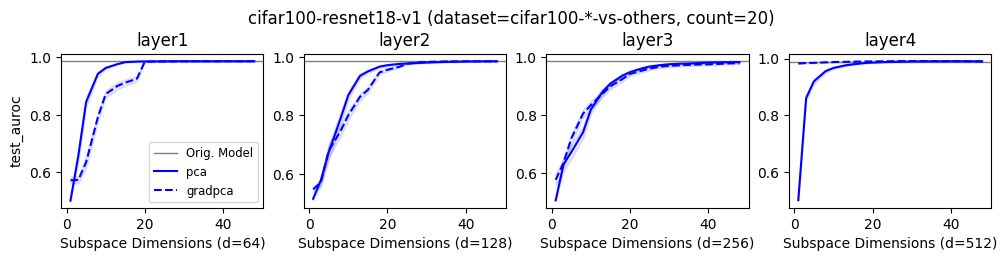

In [4]:
def alias(name):
    return name.replace("with-weight", "")
    # return {
    #     "prca-ablation-a-c": "prcaposdefv2",
    # }.get(name, name)
    
def viz(
    dataset_name="cifar100-people-vs-others",
    model_name="cifar100-resnet18-v1",
    arr_layers=["layer1", "layer2", "layer3", "layer4"], 
    arr_basis_names=[
        "pca",
        "gradpca",
        "prcaposdef",
        "prca-ablation-a-c",
        # "prcasortabs",
        # "prca",
    ],
    stat_col="test_auroc",
    ref_col="ref_auroc",
    dict_color_ls={
        "pca":        ("blue", "-"),
        "gradpca":    ("blue", "--"),
        "prcaposdef": ("red",  "-"),
        "prca-ablation-a-c": ("red",  "--"),
    }
):
    ncols = len(arr_layers)
    plt.figure(figsize=(3*ncols, 2))
    
    
   
    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix + 1)
        plt.title(layer)
        for bix, basis_name in enumerate(arr_basis_names):
            df = load_data(
                model=model_name,
                layer=layer,
                # todo: we should aggregate this over several datasets
                dataset_name=dataset_name,
                basis_name=basis_name,
                ref_col=ref_col,
                stat_col=stat_col
            )
            if bix == 0:
                plt.axhline(df[ref_col]["mean"].values[-1], ls="-", color="gray", lw=1, label="Orig. Model")
                count = df[ref_col]["count"].values[-1]
                
            d = int(df.d["mean"].values[-1])
            div = 4
            max_k = 48
            selected = df.k <= max_k
            color, ls = dict_color_ls.get(basis_name, (None, None))

            arr_k = df["k"][selected]
            mean = df[stat_col]["mean"][selected]
            sem = df[stat_col]["sem"][selected]
            plt.plot(
                arr_k,
                mean,
                label=alias(basis_name),
                color=color,
                ls=ls,
                # marker=".",
            )
            plt.fill_between(
                arr_k,
                mean - sem,
                mean + sem,
                alpha=0.1,
                color=color
            )
            
        if lix == 0:
            plt.ylabel(stat_col)
            plt.legend(fontsize="small")
        
        plt.xlabel(f"Subspace Dimensions (d={d})")
    plt.suptitle(f"{model_name} (dataset={dataset_name}, count={count})", y=1.1)

viz(dataset_name="cifar100-*-vs-others", arr_basis_names=["pca", "gradpca"])

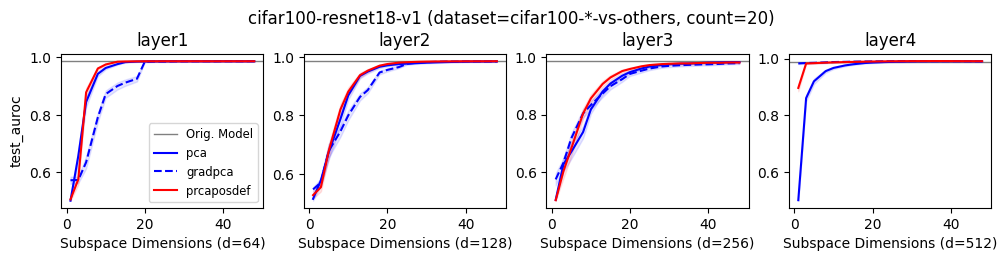

In [5]:
viz(
    dataset_name="cifar100-*-vs-others",
    arr_basis_names=[
        "pca",
        "gradpca",
        "prcaposdef"
    ]
)

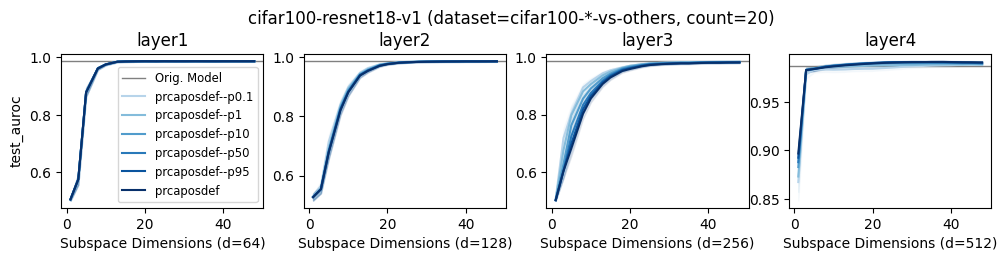

In [6]:
def ano():
        
    cmap = mpl.colormaps["Blues"]

    arr_basis_names = [
        "prcaposdef-with-weight-p0.1",
        "prcaposdef-with-weight-p1",
        "prcaposdef-with-weight-p10",
        "prcaposdef-with-weight-p50",
        "prcaposdef-with-weight-p95",
        "prcaposdef"
    ]

    scales = np.linspace(0.3, 1, len(arr_basis_names))

    ls = ["-"] * len(arr_basis_names)
    colors = list(map(lambda i: cmap(i), scales))

    
    dict_color_ls = dict(zip(arr_basis_names, list(zip(colors, ls))))
    
    viz(
        dataset_name="cifar100-*-vs-others", 
        arr_basis_names=arr_basis_names,
        dict_color_ls=dict_color_ls,
    )
ano()

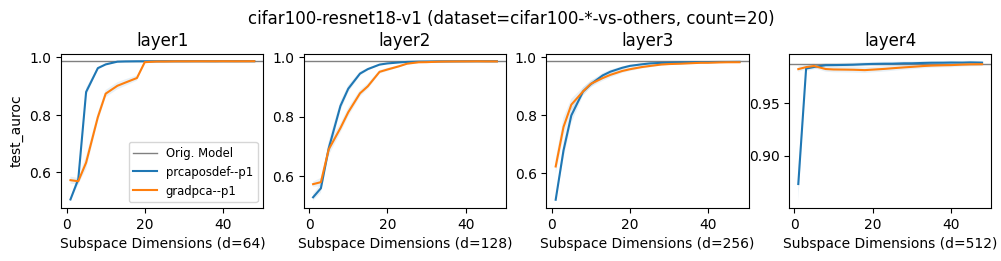

In [10]:
viz(
    dataset_name="cifar100-*-vs-others",
    arr_basis_names=[
        "prcaposdef-with-weight-p1",
        "gradpca-with-weight-p1",
    ],
)

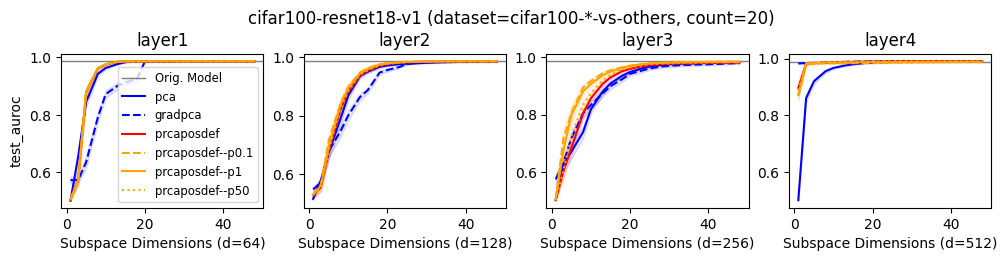

In [7]:
viz(
    dataset_name="cifar100-*-vs-others",
    arr_basis_names=[
        "pca",
        "gradpca",
        "prcaposdef",
        "prcaposdef-with-weight-p0.1",
        "prcaposdef-with-weight-p1",
        "prcaposdef-with-weight-p50",
    ],
    dict_color_ls={
        "pca":        ("blue", "-"),
        "gradpca":    ("blue", "--"),
        "prcaposdef": ("red",  "-"),
        "prcaposdef-with-weight-p1": ("orange",  "-"),
        "prcaposdef-with-weight-p0.1": ("orange",  "--"),
        "prcaposdef-with-weight-p50": ("orange",  ":"),
    }
)

# CelebA

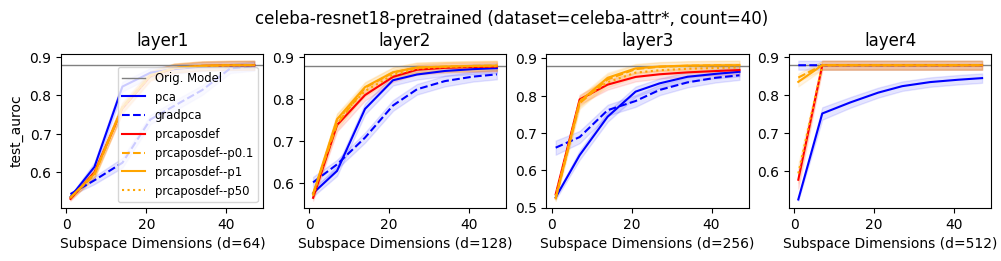

In [8]:
viz(
    model_name="celeba-resnet18-pretrained", 
    dataset_name="celeba-attr*", 
    arr_basis_names=[
        "pca",
        "gradpca",
        "prcaposdef",
        "prcaposdef-with-weight-p0.1",
        "prcaposdef-with-weight-p1",
        "prcaposdef-with-weight-p50",
    ],
    dict_color_ls={
        "pca":        ("blue", "-"),
        "gradpca":    ("blue", "--"),
        "prcaposdef": ("red",  "-"),
        "prcaposdef-with-weight-p1": ("orange",  "-"),
        "prcaposdef-with-weight-p0.1": ("orange",  "--"),
        "prcaposdef-with-weight-p50": ("orange",  ":"),
    }
)

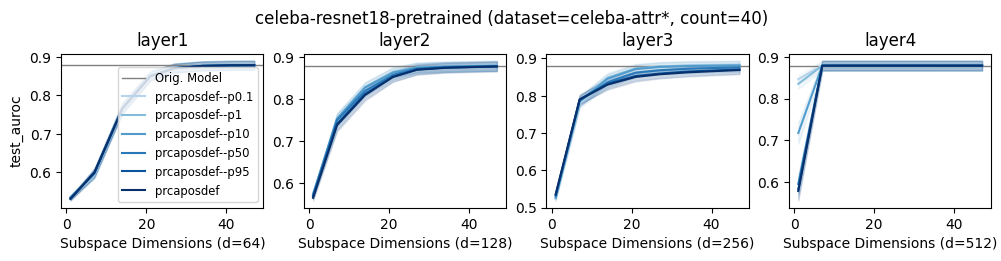

In [12]:
def ano():
        
    cmap = mpl.colormaps["Blues"]

    arr_basis_names = [
        "prcaposdef-with-weight-p0.1",
        "prcaposdef-with-weight-p1",
        "prcaposdef-with-weight-p10",
        "prcaposdef-with-weight-p50",
        "prcaposdef-with-weight-p95",
        "prcaposdef"
    ]

    scales = np.linspace(0.3, 1, len(arr_basis_names))

    ls = ["-"] * len(arr_basis_names)
    colors = list(map(lambda i: cmap(i), scales))

    
    dict_color_ls = dict(zip(arr_basis_names, list(zip(colors, ls))))
    
    viz(
        model_name="celeba-resnet18-pretrained", 
        dataset_name="celeba-attr*", 
        arr_basis_names=arr_basis_names,
        dict_color_ls=dict_color_ls,
    )
ano()

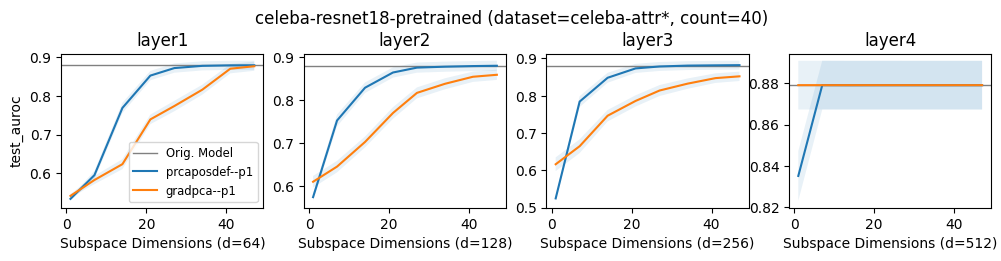

In [11]:
viz(
    model_name="celeba-resnet18-pretrained", 
    dataset_name="celeba-attr*", 
    arr_basis_names=[
        "prcaposdef-with-weight-p1",
        "gradpca-with-weight-p1",
    ],
)

In [9]:
print(f"finished at {datetime.now()}")

finished at 2025-03-17 09:19:17.021356
